In [105]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

import darling
import disell

In [106]:

base = Path(
    "~/Documents/Data/4dcells/"
    "111_june/111_cells_2_6-5pct_mosalayers_2x"
).expanduser()

print(base)
print(base.exists())

out = base / "disell_output"
out.mkdir(parents=True, exist_ok=True)

print("Output folder:", out)

/home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-5pct_mosalayers_2x
True
Output folder: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-5pct_mosalayers_2x/disell_output


In [107]:
def get_layer_number(path):
    return int(re.search(r"layer_(\d+)_", path.name).group(1))


layer_dirs = sorted(
    [p for p in base.iterdir() if p.is_dir() and p.name.startswith("layer_")],
    key=get_layer_number,
)

volume = np.stack([np.load(p / "mean.npy") for p in layer_dirs], axis=0)

print("layers:", [p.name for p in layer_dirs])
print("volume:", volume.shape)

layers: ['layer_1_1', 'layer_2_1', 'layer_3_1', 'layer_4_1', 'layer_5_1', 'layer_6_1', 'layer_7_1', 'layer_8_1', 'layer_9_1', 'layer_10_1', 'layer_11_1', 'layer_12_1']
volume: (12, 200, 500, 2)


(np.float64(-0.5), np.float64(499.5), np.float64(199.5), np.float64(-0.5))

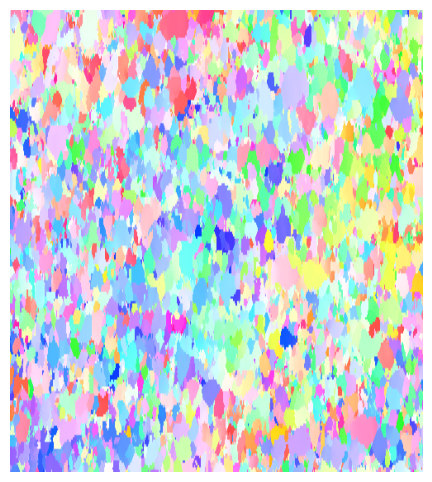

In [108]:
phi = np.linspace(np.nanmin(volume[..., 0]), np.nanmax(volume[..., 0]), 64)
chi = np.linspace(np.nanmin(volume[..., -1]), np.nanmax(volume[..., -1]), 64)
coord = np.meshgrid(phi, chi, indexing="ij")

rgb_volume = []

for z in range(volume.shape[0]):
    rgb, _, _ = darling.transforms.rgb(
        volume[z],
        norm="full",
        coordinates=coord,
    )
    rgb_volume.append(rgb)

rgb_volume = np.stack(rgb_volume, axis=0)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_volume[z], aspect=2.8)
plt.axis("off")


In [109]:
transforms = disell.register(
    volume,
    registration_channel=0,
    verbose=True,
)

registered = disell.apply_transforms(
    volume,
    transforms,
    pad_value=np.nan,
)

print("registered:", registered.shape)

[0] Shift: [ 4. -1.]
[1] Shift: [3. 0.]
[2] Shift: [2. 0.]
[3] Shift: [2. 0.]
[4] Shift: [1. 0.]
[5] Shift: [0. 0.]
[7] Shift: [0. 0.]
[8] Shift: [-1.  0.]
[9] Shift: [-2.  0.]
[10] Shift: [39. 76.]
[11] Shift: [-3.  0.]
registered: (12, 200, 500, 2)


In [110]:
mask = np.all(np.isfinite(registered), axis=-1)

seg_input = registered.copy()

for c in range(seg_input.shape[-1]):
    vals = seg_input[..., c][mask]
    lo, hi = np.nanpercentile(vals, [1, 99])
    seg_input[..., c] = (seg_input[..., c] - lo) / (hi - lo)

seg_input[~np.isfinite(seg_input)] = 0

In [111]:
footprint = np.ones((3, 3, 3), dtype=bool)

footprint[1, :, :] = True

footprint[0, :, 1] = True
footprint[0, 1, :] = True
footprint[2, 1, :] = True
footprint[2, :, 1] = True


In [112]:
import numpy as np
from skimage.segmentation import relabel_sequential


marker_result, sizes_initial = disell.flood_fill_dfxm_two_stage(
    seg_input,
    footprint=footprint,
    local_misorientation_threshold=0.015,
    global_threshold=0.3,
    footprint_tolerance=0.85,
    mask=mask,
    max_iterations=50_000,
    min_grain_size=4,
    recycle_small_grains=False,
    stagnation_tolerance=1000,
)

markers = marker_result["segmentation"]
mask_bool = mask.astype(bool)


kam_volume = disell.kam(seg_input, ndim=3, size=(3, 3, 3))
kam_volume = np.asarray(kam_volume)

if kam_volume.shape == markers.shape + (1,):
    kam_volume = kam_volume[..., 0]

assert kam_volume.shape == markers.shape

watershed_feature = np.asarray(kam_volume, dtype=float).copy()
finite_inside = np.isfinite(watershed_feature[mask_bool])
if np.any(finite_inside):
    fill_value = np.nanmax(watershed_feature[mask_bool][finite_inside])
else:
    fill_value = 1.0
watershed_feature[~np.isfinite(watershed_feature)] = fill_value


final_labels = disell.region_grow_watershed(
    seg=markers,
    mask=mask_bool,
    feature=watershed_feature,
    connectivity=1,
)
final_labels = final_labels.astype(np.int32, copy=False)

# Make labels contiguous for easier downstream analysis.
final_labels, _fw, _inv = relabel_sequential(final_labels)
final_labels = np.asarray(final_labels)

print("markers shape:", markers.shape)
print("number of marker labels:", int(markers.max()))
print("number of final labels:", int(final_labels.max()))

markers shape: (12, 200, 500)
number of marker labels: 2973
number of final labels: 2973


In [113]:
# ---- KAM / feature diagnostics ----
print("KAM volume shape:", kam_volume.shape)

finite_fraction = (
    np.count_nonzero(np.isfinite(kam_volume[mask_bool]))
    / np.count_nonzero(mask_bool)
)
print(f"KAM finite fraction inside mask: {finite_fraction:.3f}")
print(
    "KAM min/max inside mask:",
    np.nanmin(kam_volume[mask_bool]),
    np.nanmax(kam_volume[mask_bool]),
)

# ---- shape / content sanity checks ----
assert markers.shape == mask_bool.shape
assert kam_volume.shape == mask_bool.shape
assert watershed_feature.shape == mask_bool.shape
assert final_labels.shape == mask_bool.shape
assert np.count_nonzero(markers > 0) > 0

# ---- mask-aware coverage (divide by valid mask, not the full rectangular array) ----
marker_fraction = (
    np.count_nonzero((markers > 0) & mask_bool)
    / np.count_nonzero(mask_bool)
)
final_fraction = (
    np.count_nonzero((final_labels > 0) & mask_bool)
    / np.count_nonzero(mask_bool)
)

print("markers shape:", markers.shape)
print("number of marker labels:", int(markers.max()))
print("number of final labels:", int(final_labels.max()))
print(f"Marker coverage inside mask: {100 * marker_fraction:.1f}%")
print(f"Final coverage inside mask: {100 * final_fraction:.1f}%")

# The marker coverage may be ~50% (that is fine). The watershed-refined final
# coverage should be ~100% inside the mask. If not, report what went wrong.
if final_fraction < 0.99:
    print("\n[WARNING] Final coverage is below 99% inside the mask:")
    print("  number of marker labels:", int(markers.max()))
    print(f"  marker coverage inside mask: {100 * marker_fraction:.1f}%")
    print(f"  final coverage inside mask: {100 * final_fraction:.1f}%")
    print(
        "  NaNs in KAM/feature inside mask:",
        int(np.count_nonzero(~np.isfinite(kam_volume[mask_bool]))),
    )
    print("  True voxels in mask:", int(np.count_nonzero(mask_bool)))

# Convenience alias: downstream cells operate on the FINAL segmentation.
labels = final_labels

KAM volume shape: (12, 200, 500)
KAM finite fraction inside mask: 1.000
KAM min/max inside mask: 0.0 1.2498659803915215
markers shape: (12, 200, 500)
number of marker labels: 2973
number of final labels: 2973
Marker coverage inside mask: 31.8%
Final coverage inside mask: 100.0%


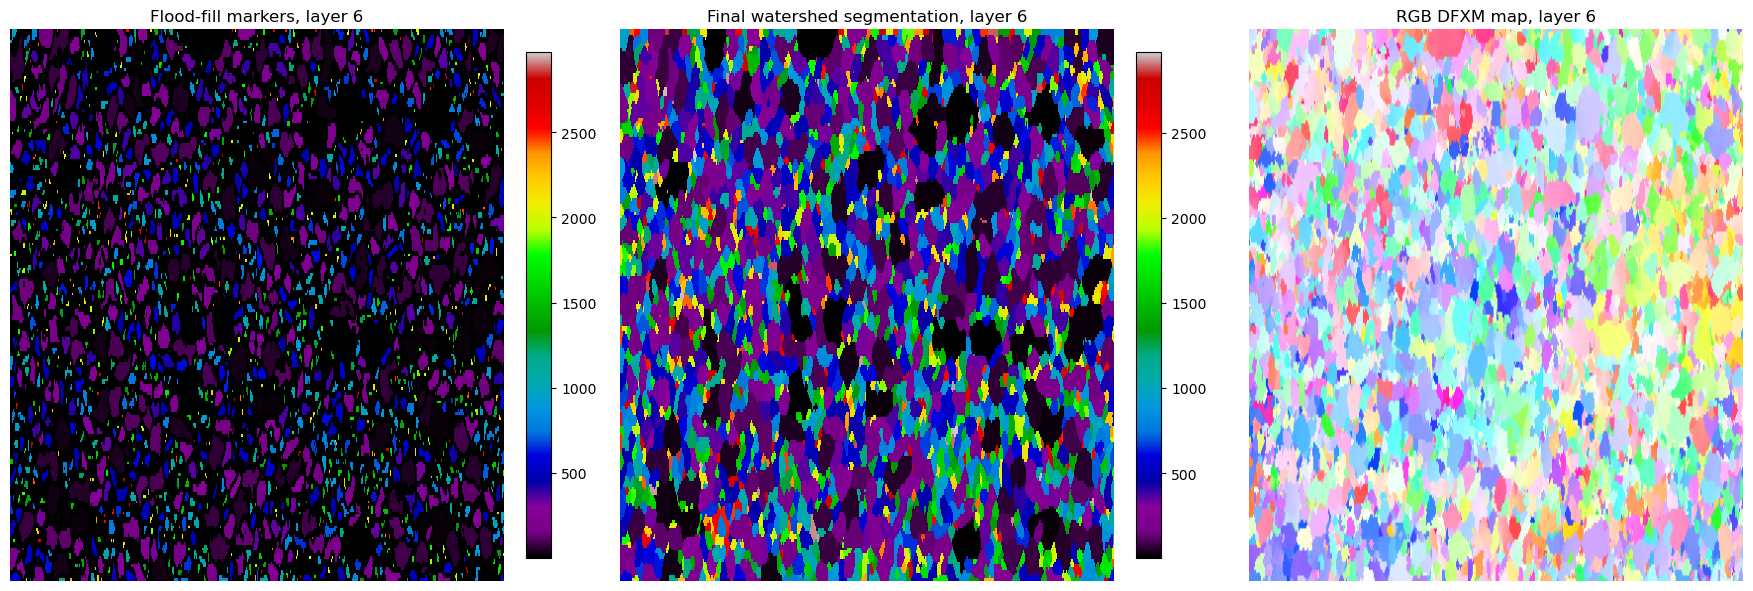

In [114]:
import matplotlib as mpl
import matplotlib.pyplot as plt

z = final_labels.shape[0] // 2

# Choose zoom region in (y, x)
y0, y1 = 0, -1
x0, x1 = 0, -1

markers_crop = markers[z, y0:y1, x0:x1]
final_crop = final_labels[z, y0:y1, x0:x1]
rgb_crop = rgb_volume[z, y0:y1, x0:x1]

# Copy colormap and set label 0 to black
cmap = mpl.colormaps["nipy_spectral"].copy()
cmap.set_under("black")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(
    markers_crop,
    cmap=cmap,
    interpolation="nearest",
    aspect=2.8,
    vmin=0.5,   # values below this, i.e. label 0, use set_under colour
)
axes[0].set_title(f"Flood-fill markers, layer {z}")
axes[0].axis("off")

im1 = axes[1].imshow(
    final_crop,
    cmap=cmap,
    interpolation="nearest",
    aspect=2.8,
    vmin=0.5,
)
axes[1].set_title(f"Final watershed segmentation, layer {z}")
axes[1].axis("off")

axes[2].imshow(rgb_crop, aspect=2.8)
axes[2].set_title(f"RGB DFXM map, layer {z}")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

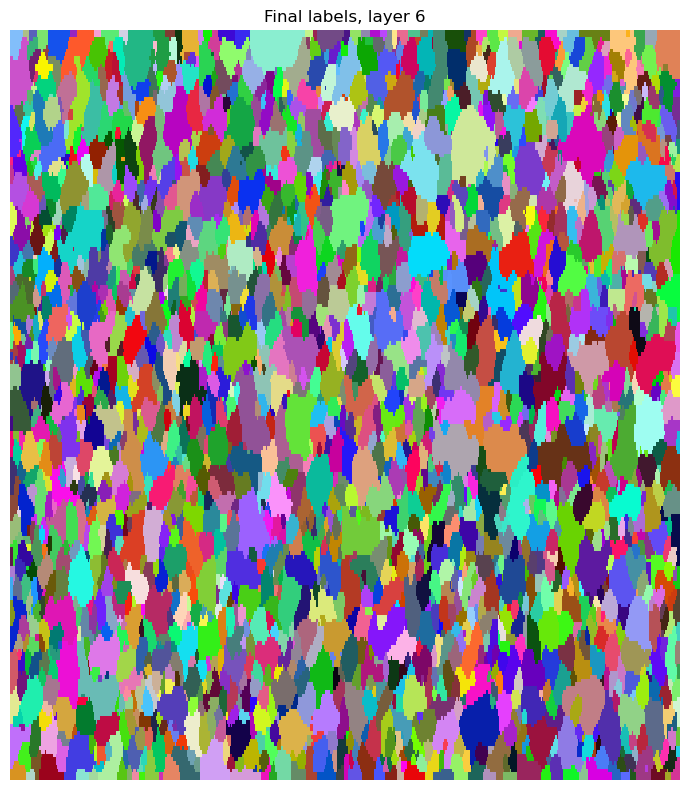

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def random_label_cmap(n_labels, seed=0):
    rng = np.random.default_rng(seed)
    colors = rng.random((n_labels + 1, 4))
    colors[:, 3] = 1.0
    colors[0] = [0, 0, 0, 1]  # label 0 = black
    return mpl.colors.ListedColormap(colors)

z = final_labels.shape[0] // 2

cmap_labels = random_label_cmap(int(final_labels.max()), seed=0)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    final_labels[z],
    cmap=cmap_labels,
    interpolation="nearest",
    aspect=2.8,
    vmin=0,
    vmax=final_labels.max(),
)
ax.set_title(f"Final labels, layer {z}")
ax.axis("off")
plt.tight_layout()
plt.show()

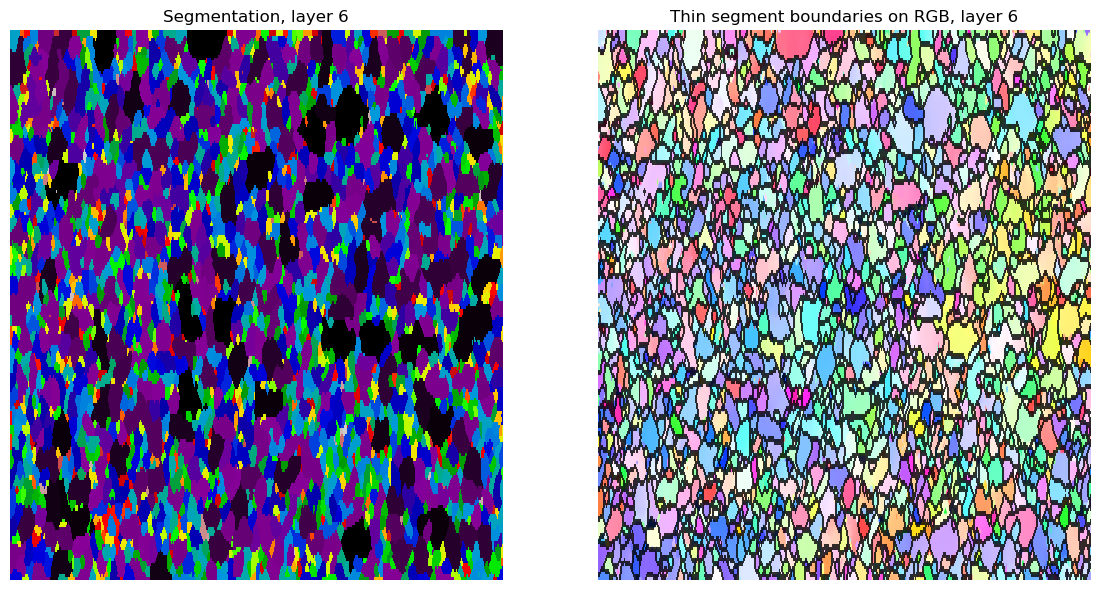

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

z = labels.shape[0] // 2

y0, y1 = 0, -1
x0, x1 = 0, -1

labels_crop = labels[z, y0:y1, x0:x1]
rgb_crop = rgb_volume[z, y0:y1, x0:x1]

# Thin 1-pixel boundaries
boundaries = find_boundaries(
    labels_crop,
    mode="inner",
    background=0,
)

# Only keep boundaries inside segmented regions
boundaries = boundaries & (labels_crop > 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(labels_crop, cmap="nipy_spectral", interpolation="nearest", aspect=2.8)
axes[0].set_title(f"Segmentation, layer {z}")
axes[0].axis("off")

axes[1].imshow(rgb_crop, aspect=2.8)

boundary_overlay = np.zeros((*boundaries.shape, 4))
boundary_overlay[boundaries] = [0, 0, 0, 0.8]  # black, slightly transparent

axes[1].imshow(boundary_overlay, interpolation="nearest", aspect=2.8)
axes[1].set_title(f"Thin segment boundaries on RGB, layer {z}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Number of segmented cells in layer 7: 2073
Median cell area: 30.0 pixels
Mean cell area: 48.2 pixels


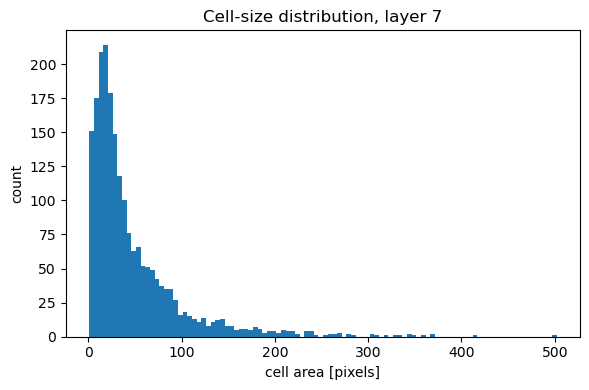

In [117]:
z = (labels.shape[0] // 2)+1

labels_z = labels[z]

# Count pixels per label
label_ids, counts = np.unique(labels_z, return_counts=True)

# Remove background label 0
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_px = counts[valid]

print(f"Number of segmented cells in layer {z}: {len(cell_sizes_px)}")
print(f"Median cell area: {np.median(cell_sizes_px):.1f} pixels")
print(f"Mean cell area: {np.mean(cell_sizes_px):.1f} pixels")

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_px, bins=100)
plt.xlabel("cell area [pixels]")
plt.ylabel("count")
plt.title(f"Cell-size distribution, layer {z}")
plt.tight_layout()
plt.show()

Number of segmented 3D cells: 2973
Min cell volume: 4 voxels
Median cell volume: 182.0 voxels
Mean cell volume: 389.9 voxels
Max cell volume: 8662 voxels


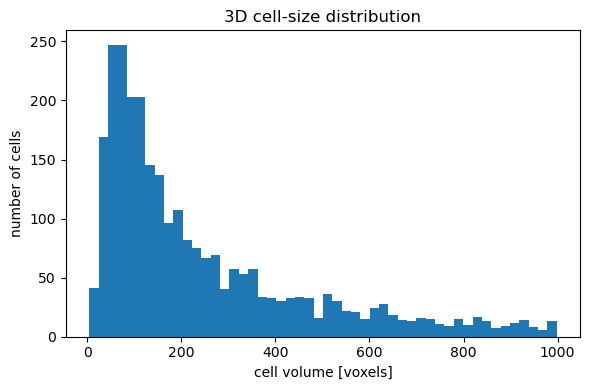

In [118]:
label_ids, counts = np.unique(labels, return_counts=True)

# Remove background / unsegmented label
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_vox = counts[valid]

print(f"Number of segmented 3D cells: {len(cell_sizes_vox)}")
print(f"Min cell volume: {cell_sizes_vox.min()} voxels")
print(f"Median cell volume: {np.median(cell_sizes_vox):.1f} voxels")
print(f"Mean cell volume: {np.mean(cell_sizes_vox):.1f} voxels")
print(f"Max cell volume: {cell_sizes_vox.max()} voxels")

upper = np.percentile(cell_sizes_vox, 90)

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_vox[cell_sizes_vox <= 1000], bins=50)
plt.xlabel("cell volume [voxels]")
plt.ylabel("number of cells")
plt.title("3D cell-size distribution")
plt.tight_layout()
plt.show()

In [119]:
from scipy import ndimage as ndi
import numpy as np

# Use same connectivity as your segmentation / physical neighbourhood
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True      # full in-plane 8-connectivity
structure[0, 1, 1] = True      # z-1 same x,y
structure[2, 1, 1] = True      # z+1 same x,y

n_disconnected_labels = 0
n_extra_components = 0

for old_label in np.unique(labels):
    if old_label == 0:
        continue

    cc, n_cc = ndi.label(labels == old_label, structure=structure)

    if n_cc > 1:
        n_disconnected_labels += 1
        n_extra_components += n_cc - 1

print("labels:", int(labels.max()))
print("labels with >1 connected component:", n_disconnected_labels)
print("extra disconnected components:", n_extra_components)

labels: 2973
labels with >1 connected component: 6
extra disconnected components: 7


In [120]:
from scipy import ndimage as ndi
import numpy as np

# Same connectivity as before:
# - full 8-connectivity in-plane
# - direct z-neighbour connectivity between layers
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

labels_split = np.zeros_like(labels, dtype=np.int32)

new_label = 1
split_info = []

for old_label in np.unique(labels):
    if old_label == 0:
        continue

    old_mask = labels == old_label
    cc, n_cc = ndi.label(old_mask, structure=structure)

    if n_cc > 1:
        sizes = np.bincount(cc.ravel())[1:]
        split_info.append((old_label, n_cc, sizes))

    for component_id in range(1, n_cc + 1):
        component = cc == component_id
        labels_split[component] = new_label
        new_label += 1

print("old max label:", int(labels.max()))
print("new max label:", int(labels_split.max()))
print("labels split:", len(split_info))
print("extra components:", int(labels_split.max() - labels.max()))

coverage_before = np.count_nonzero((labels > 0) & mask_bool) / np.count_nonzero(mask_bool)
coverage_after = np.count_nonzero((labels_split > 0) & mask_bool) / np.count_nonzero(mask_bool)

print(f"coverage before: {coverage_before:.4%}")
print(f"coverage after:  {coverage_after:.4%}")

old max label: 2973
new max label: 2980
labels split: 6
extra components: 7
coverage before: 100.0000%
coverage after:  100.0000%


In [121]:
labels = labels_split

In [122]:
import pyvista as pv

In [123]:
phi = np.linspace(np.nanmin(registered[..., 0]), np.nanmax(registered[..., 0]), 64)
chi = np.linspace(np.nanmin(registered[..., -1]), np.nanmax(registered[..., -1]), 64)
coord = np.meshgrid(phi, chi, indexing="ij")

rgb_volume = []

for z in range(registered.shape[0]):
    rgb, colorkey, colorgrid = darling.transforms.rgb(
        registered[z],
        norm="full",
        coordinates=coord,
    )
    rgb_volume.append(rgb)

rgb_volume = np.stack(rgb_volume, axis=0)

print("rgb_volume:", rgb_volume.shape)
print("labels:", labels.shape)

rgb_volume: (12, 200, 500, 3)
labels: (12, 200, 500)


In [124]:
ids, counts = np.unique(labels, return_counts=True)

# Remove background
keep = ids != 0
ids = ids[keep]
counts = counts[keep]

order = np.argsort(counts)[::-1]

for i in range(min(20, len(ids))):
    print(f"label {ids[order[i]]}: {counts[order[i]]} voxels")

label 569: 8662 voxels
label 256: 6191 voxels
label 737: 6178 voxels
label 328: 6050 voxels
label 2101: 5123 voxels
label 1177: 4832 voxels
label 1: 4807 voxels
label 1091: 4086 voxels
label 541: 4076 voxels
label 3: 3710 voxels
label 1631: 3540 voxels
label 2375: 3515 voxels
label 906: 3512 voxels
label 4: 3475 voxels
label 2387: 3451 voxels
label 5: 3440 voxels
label 6: 3416 voxels
label 10: 3400 voxels
label 644: 3386 voxels
label 7: 3328 voxels


In [125]:
cell_id = ids[order[0]]
print("chosen cell:", cell_id)

chosen cell: 569


In [126]:
cell_mask = labels == cell_id

zz, yy, xx = np.nonzero(cell_mask)

points = np.column_stack([xx, yy, zz]).astype(float)
colors = rgb_volume[cell_mask]

print("points:", points.shape)
print("colors:", colors.shape)

points: (8662, 3)
colors: (8662, 3)


/tmp/ipykernel_157684/95477042.py:14: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


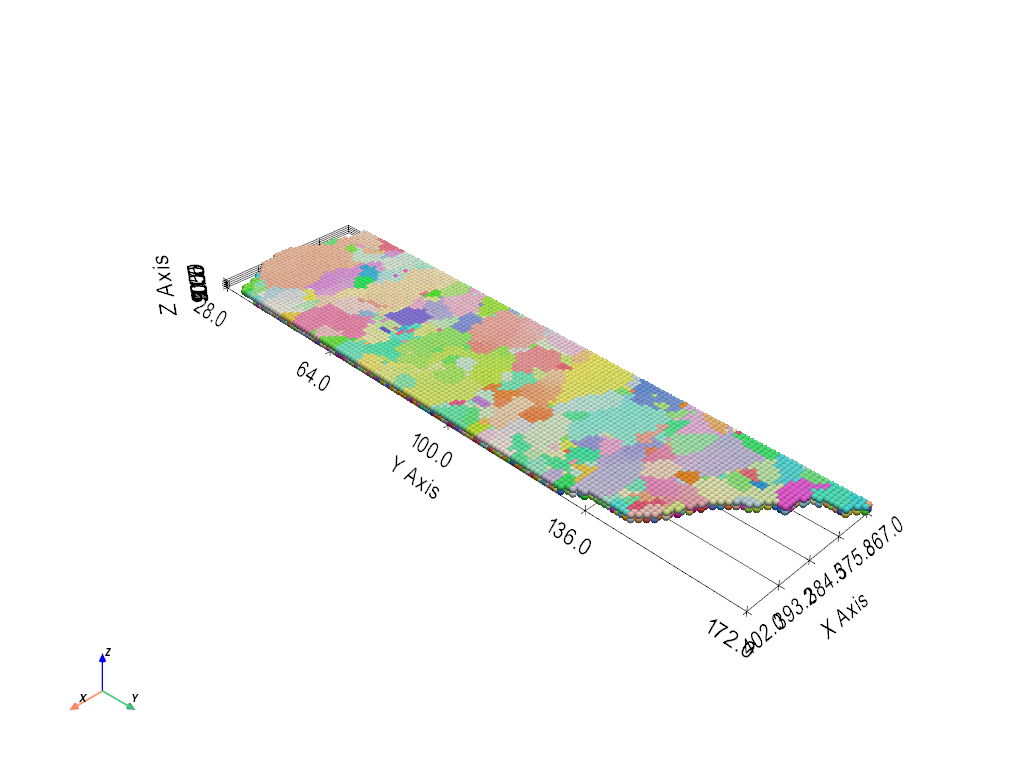

In [127]:
cloud = pv.PolyData(points)
cloud["RGB"] = (np.clip(colors, 0, 1) * 255).astype(np.uint8)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    scalars="RGB",
    rgb=True,
    point_size=8,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()

cell_id = 569
number of voxels in this cell = 8662
valid voxels = 8662
phi range: -0.5801 to 1.4202
chi range: 7.1501 to 9.3100


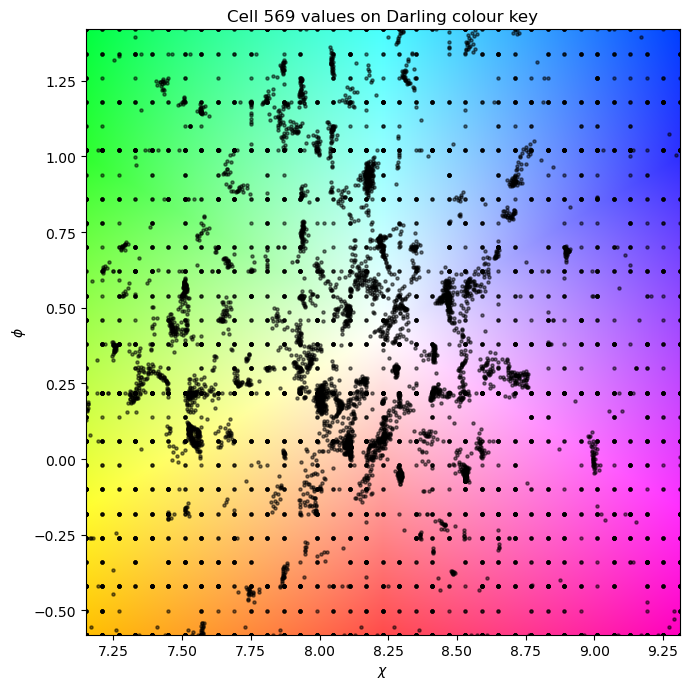

In [128]:
cell_id = cell_id  # the cell you want

# Extract only this cell
mask = labels == cell_id
zz, yy, xx = np.nonzero(mask)

print(f"cell_id = {cell_id}")
print(f"number of voxels in this cell = {len(xx)}")

if len(xx) == 0:
    raise ValueError(f"No voxels found for cell_id={cell_id}. Check that this label exists.")

# Extract only this cell's values
cell_values = registered[zz, yy, xx]

cell_phi = cell_values[..., 0]
cell_chi = cell_values[..., -1]

valid = ~np.isnan(cell_phi) & ~np.isnan(cell_chi)

print(f"valid voxels = {np.count_nonzero(valid)}")
print(f"phi range: {np.nanmin(cell_phi):.4f} to {np.nanmax(cell_phi):.4f}")
print(f"chi range: {np.nanmin(cell_chi):.4f} to {np.nanmax(cell_chi):.4f}")

fig, ax = plt.subplots(figsize=(7, 7))

# Show Darling colour key
ax.imshow(
    colorkey,
    origin="lower",
    extent=[
        np.nanmin(chi),
        np.nanmax(chi),
        np.nanmin(phi),
        np.nanmax(phi),
    ],
    aspect="auto",
)

# Overlay only selected cell values
ax.scatter(
    cell_chi[valid],
    cell_phi[valid],
    s=5,
    c="black",
    alpha=0.5,
)

ax.set_xlabel(r"$\chi$")
ax.set_ylabel(r"$\phi$")
ax.set_title(f"Cell {cell_id} values on Darling colour key")

plt.tight_layout()
plt.show()

In [129]:
from scipy import ndimage as ndi
import numpy as np

cell_id = int(ids[order[0]])
cell_mask = labels == cell_id

# Same connectivity idea as your segmentation footprint
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

cc, n_cc = ndi.label(cell_mask, structure=structure)

print("cell_id:", cell_id)
print("number of disconnected components:", n_cc)

component_sizes = np.bincount(cc.ravel())[1:]
print("component sizes:", component_sizes)

cell_id: 569
number of disconnected components: 1
component sizes: [8662]


In [130]:
out = base / "disell_3d_output"
out.mkdir(exist_ok=True)

np.save(out / "labels_cc.npy", labels)
np.save(out / "rgb_volume.npy", rgb_volume)

print("saved arrays to:", out)

saved arrays to: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-5pct_mosalayers_2x/disell_3d_output


In [131]:
labels_to_export = labels

# Export only segmented voxels
mask_export = labels_to_export > 0

zz, yy, xx = np.nonzero(mask_export)

# Physical spacing. Replace these with real values if you know them.
dx = 1.0
dy = 1.0
dz = 1.0

points = np.column_stack([
    xx * dx,
    yy * dy,
    zz * dz,
]).astype(np.float32)

colors = rgb_volume[mask_export]
colors_uint8 = (np.clip(colors, 0, 1) * 255).astype(np.uint8)

label_values = labels_to_export[mask_export].astype(np.int32)

cloud = pv.PolyData(points)
cloud["RGB"] = colors_uint8
cloud["label"] = label_values

vtp_path = out / "segmentation_rgb_pointcloud.vtp"
cloud.save(vtp_path)

print("saved:", vtp_path)
print("points:", points.shape[0])

saved: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-5pct_mosalayers_2x/disell_3d_output/segmentation_rgb_pointcloud.vtp
points: 1159068


/tmp/ipykernel_157684/2684211306.py:11: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


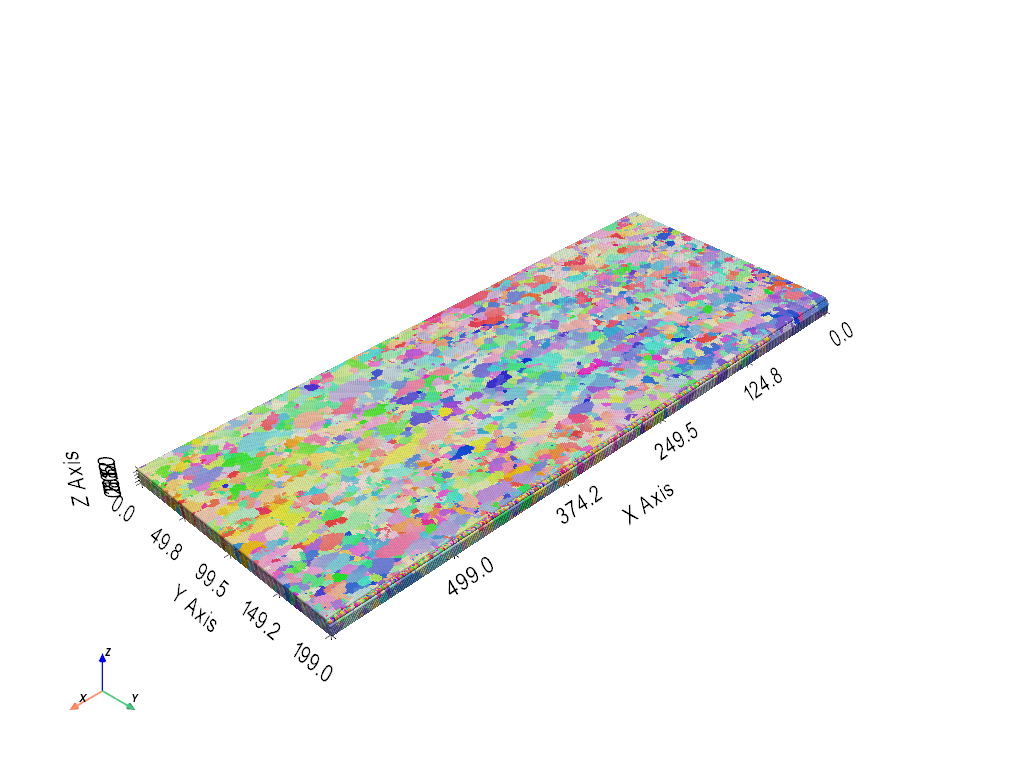

In [132]:
plotter = pv.Plotter()
plotter.add_points(
    cloud,
    scalars="RGB",
    rgb=True,
    point_size=4,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()

using neighbour offsets: [(0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (-1, 0, 0)]
number of cells: 2980
feature channels: 2
neighbour pairs: 14916
valid neighbour-pair misorientations: 14916
mean neighbour misorientation: 0.35584470709765603
median neighbour misorientation: 0.33429369812261217
std neighbour misorientation: 0.19886529565808264

Per-cell neighbour misorientation:
cells with neighbours: 2980
mean of per-cell mean neighbour misorientation: 0.36331901716232473
median of per-cell mean neighbour misorientation: 0.345614661414523


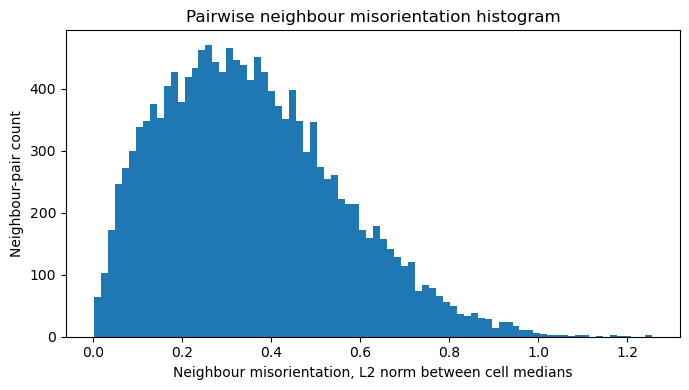

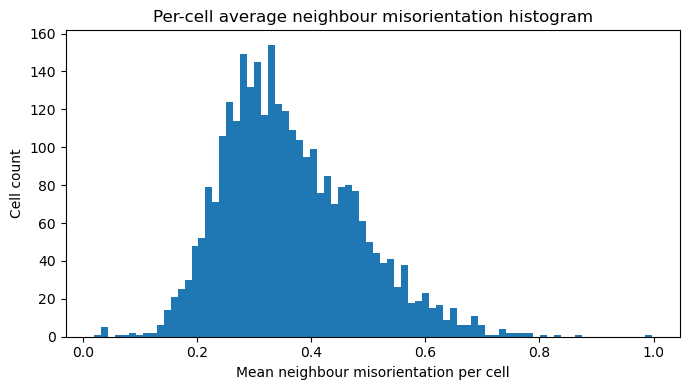

,label_a,label_b,misorientation,size_a,size_b
0,1,35,0.358610,4807,1819
1,1,152,0.390909,4807,1047
2,1,193,0.265009,4807,916
3,1,256,0.157500,4807,6191
4,1,259,0.419111,4807,785


,label,n_neighbours,mean_neighbour_misorientation,median_neighbour_misorientation,std_neighbour_misorientation,cell_size
0,1,34,0.333645,0.353312,0.139460,4807
1,2,13,0.506553,0.473170,0.192179,3291
2,3,25,0.411702,0.405253,0.186628,3710
3,4,24,0.354171,0.293224,0.192593,3475
4,5,26,0.332790,0.333073,0.178754,3440


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi


# ---------------------------------------------------------------------
# Inputs expected:
#   labels     : final 3D labelled segmentation, shape (Z, Y, X)
#   seg_input  : DFXM property volume, shape (Z, Y, X, C)
#   mask_bool  : valid data mask, shape (Z, Y, X)
#
# If needed:
# labels = labels_split
# ---------------------------------------------------------------------

labels = np.asarray(labels, dtype=np.int32)
features = np.asarray(seg_input, dtype=float)
mask_bool = np.asarray(mask_bool, dtype=bool)

assert labels.ndim == 3
assert features.ndim == 4
assert labels.shape == features.shape[:3]
assert labels.shape == mask_bool.shape


# ---------------------------------------------------------------------
# Connectivity definition
# Same logic as before:
#   - full 8-connectivity inside each z layer
#   - direct z-neighbour connection between adjacent layers
#
# This avoids treating diagonal inter-layer contacts as neighbours.
# ---------------------------------------------------------------------

offsets = []

# in-plane 8-connectivity
for dy in [-1, 0, 1]:
    for dx in [-1, 0, 1]:
        if dy == 0 and dx == 0:
            continue
        offsets.append((0, dy, dx))

# direct z-connectivity
offsets.append((-1, 0, 0))
offsets.append((1, 0, 0))

# Keep only one direction from each opposite pair to avoid duplicate work
unique_offsets = []
seen = set()
for dz, dy, dx in offsets:
    a = (dz, dy, dx)
    b = (-dz, -dy, -dx)
    if b in seen:
        continue
    seen.add(a)
    unique_offsets.append(a)

print("using neighbour offsets:", unique_offsets)


# ---------------------------------------------------------------------
# Compute median feature vector per label
# ---------------------------------------------------------------------

label_ids = np.unique(labels[(labels > 0) & mask_bool])
n_labels = int(label_ids.max())

cell_medians = np.full((n_labels + 1, features.shape[-1]), np.nan, dtype=float)
cell_sizes = np.zeros(n_labels + 1, dtype=np.int64)

for lab in label_ids:
    region = (labels == lab) & mask_bool
    vals = features[region]

    # Remove voxels with any non-finite channel
    finite = np.all(np.isfinite(vals), axis=1)
    vals = vals[finite]

    cell_sizes[lab] = vals.shape[0]

    if vals.shape[0] > 0:
        cell_medians[lab] = np.nanmedian(vals, axis=0)

print("number of cells:", len(label_ids))
print("feature channels:", features.shape[-1])


# ---------------------------------------------------------------------
# Find neighbouring label pairs from shifted label comparisons
# ---------------------------------------------------------------------

pairs = set()

Z, Y, X = labels.shape

for dz, dy, dx in unique_offsets:
    z0a = max(0, dz)
    z1a = Z + min(0, dz)
    y0a = max(0, dy)
    y1a = Y + min(0, dy)
    x0a = max(0, dx)
    x1a = X + min(0, dx)

    z0b = max(0, -dz)
    z1b = Z + min(0, -dz)
    y0b = max(0, -dy)
    y1b = Y + min(0, -dy)
    x0b = max(0, -dx)
    x1b = X + min(0, -dx)

    a = labels[z0a:z1a, y0a:y1a, x0a:x1a]
    b = labels[z0b:z1b, y0b:y1b, x0b:x1b]

    ma = mask_bool[z0a:z1a, y0a:y1a, x0a:x1a]
    mb = mask_bool[z0b:z1b, y0b:y1b, x0b:x1b]

    contact = (a > 0) & (b > 0) & (a != b) & ma & mb

    if not np.any(contact):
        continue

    aa = a[contact].astype(np.int64)
    bb = b[contact].astype(np.int64)

    lo = np.minimum(aa, bb)
    hi = np.maximum(aa, bb)

    for p in zip(lo, hi):
        pairs.add(p)

pairs = np.array(sorted(pairs), dtype=np.int64)

print("neighbour pairs:", len(pairs))


# ---------------------------------------------------------------------
# Compute neighbour misorientation
# Here: L2 norm between median feature vectors.
# ---------------------------------------------------------------------

rows = []

for lab_a, lab_b in pairs:
    fa = cell_medians[lab_a]
    fb = cell_medians[lab_b]

    if not (np.all(np.isfinite(fa)) and np.all(np.isfinite(fb))):
        continue

    dvec = fb - fa
    mis = np.linalg.norm(dvec)

    rows.append(
        {
            "label_a": int(lab_a),
            "label_b": int(lab_b),
            "misorientation": float(mis),
            "size_a": int(cell_sizes[lab_a]),
            "size_b": int(cell_sizes[lab_b]),
        }
    )

neighbour_df = pd.DataFrame(rows)

print("valid neighbour-pair misorientations:", len(neighbour_df))
print("mean neighbour misorientation:", neighbour_df["misorientation"].mean())
print("median neighbour misorientation:", neighbour_df["misorientation"].median())
print("std neighbour misorientation:", neighbour_df["misorientation"].std())


# ---------------------------------------------------------------------
# Average neighbour misorientation per cell
# ---------------------------------------------------------------------

per_cell_rows = []

for lab in label_ids:
    lab = int(lab)

    m = (neighbour_df["label_a"] == lab) | (neighbour_df["label_b"] == lab)
    vals = neighbour_df.loc[m, "misorientation"].to_numpy()

    if vals.size == 0:
        continue

    per_cell_rows.append(
        {
            "label": lab,
            "n_neighbours": int(vals.size),
            "mean_neighbour_misorientation": float(np.mean(vals)),
            "median_neighbour_misorientation": float(np.median(vals)),
            "std_neighbour_misorientation": float(np.std(vals)),
            "cell_size": int(cell_sizes[lab]),
        }
    )

cell_neighbour_df = pd.DataFrame(per_cell_rows)

print("\nPer-cell neighbour misorientation:")
print("cells with neighbours:", len(cell_neighbour_df))
print(
    "mean of per-cell mean neighbour misorientation:",
    cell_neighbour_df["mean_neighbour_misorientation"].mean(),
)
print(
    "median of per-cell mean neighbour misorientation:",
    cell_neighbour_df["mean_neighbour_misorientation"].median(),
)


# ---------------------------------------------------------------------
# Histograms
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(neighbour_df["misorientation"], bins=80)
ax.set_xlabel("Neighbour misorientation, L2 norm between cell medians")
ax.set_ylabel("Neighbour-pair count")
ax.set_title("Pairwise neighbour misorientation histogram")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cell_neighbour_df["mean_neighbour_misorientation"], bins=80)
ax.set_xlabel("Mean neighbour misorientation per cell")
ax.set_ylabel("Cell count")
ax.set_title("Per-cell average neighbour misorientation histogram")
plt.tight_layout()
plt.show()


# Optional: quick preview tables
display(neighbour_df.head())
display(cell_neighbour_df.head())

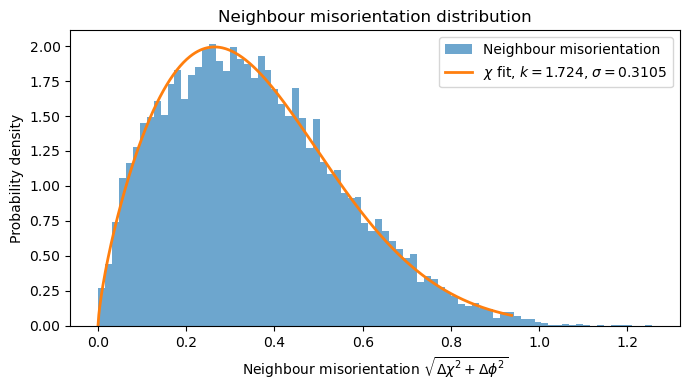

Chi k / df:      1.7239
Chi sigma:       0.3105
Chi loc:         0.0000
empirical mean:  0.3558
Chi mean:        0.3548
empirical std:   0.1989
Chi std:         0.2007
empirical median:0.3343
Chi median:      0.3287


In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mis = neighbour_df["misorientation"].to_numpy()
mis = mis[np.isfinite(mis)]
mis = mis[mis > 0]

# ---------------------------------------------------------------------
# Chi-distribution fit
# scipy.stats.chi has parameters:
#   df    = k, degrees of freedom
#   loc   = location, fixed to 0 here
#   scale = sigma
#
# Fix loc=0 because misorientation is non-negative and should start at zero.
# ---------------------------------------------------------------------

k_hat, loc_hat, sigma_hat = stats.chi.fit(mis, floc=0)

x = np.linspace(0, np.percentile(mis, 99.5), 500)
pdf_chi = stats.chi.pdf(x, df=k_hat, loc=0, scale=sigma_hat)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    mis,
    bins=80,
    density=True,
    alpha=0.65,
    label="Neighbour misorientation",
)

ax.plot(
    x,
    pdf_chi,
    linewidth=2,
    label=fr"$\chi$ fit, $k={k_hat:.3f}$, $\sigma={sigma_hat:.4f}$",
)

ax.set_xlabel(r"Neighbour misorientation $\sqrt{\Delta\chi^2 + \Delta\phi^2}$")
ax.set_ylabel("Probability density")
ax.set_title("Neighbour misorientation distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Chi k / df:      {k_hat:.4f}")
print(f"Chi sigma:       {sigma_hat:.4f}")
print(f"Chi loc:         {loc_hat:.4f}")
print(f"empirical mean:  {np.mean(mis):.4f}")
print(f"Chi mean:        {stats.chi.mean(df=k_hat, loc=0, scale=sigma_hat):.4f}")
print(f"empirical std:   {np.std(mis):.4f}")
print(f"Chi std:         {stats.chi.std(df=k_hat, loc=0, scale=sigma_hat):.4f}")
print(f"empirical median:{np.median(mis):.4f}")
print(f"Chi median:      {stats.chi.median(df=k_hat, loc=0, scale=sigma_hat):.4f}")

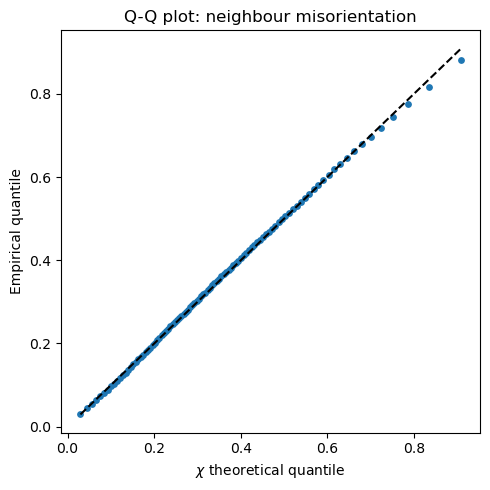

In [135]:
qs = np.linspace(0.01, 0.99, 99)

emp_q = np.quantile(mis, qs)
chi_q = stats.chi.ppf(qs, df=k_hat, loc=0, scale=sigma_hat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(chi_q, emp_q, s=15)
ax.plot(
    [chi_q.min(), chi_q.max()],
    [chi_q.min(), chi_q.max()],
    "k--",
)
ax.set_xlabel(r"$\chi$ theoretical quantile")
ax.set_ylabel("Empirical quantile")
ax.set_title("Q-Q plot: neighbour misorientation")
plt.tight_layout()
plt.show()

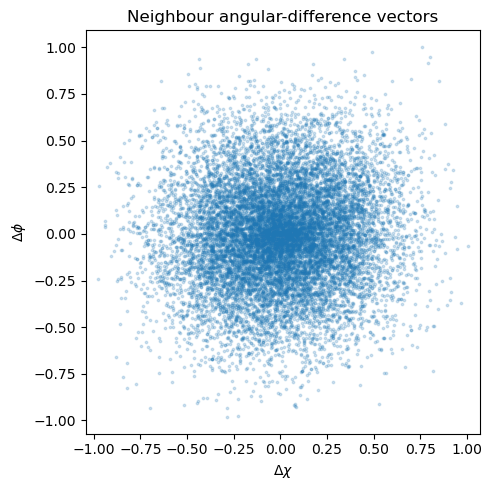

mean Δχ: -0.0026270238203590793
mean Δφ: -0.005367686166096094
std Δχ: 0.29669510643269864
std Δφ: 0.27947542030618794
corr Δχ, Δφ: 0.056865133956914685


In [136]:
dchi = []
dphi = []

for _, row in neighbour_df.iterrows():
    a = int(row["label_a"])
    b = int(row["label_b"])

    fa = cell_medians[a]
    fb = cell_medians[b]

    dchi.append(fb[0] - fa[0])
    dphi.append(fb[1] - fa[1])

dchi = np.asarray(dchi)
dphi = np.asarray(dphi)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(dchi, dphi, s=3, alpha=0.2)
ax.set_xlabel(r"$\Delta\chi$")
ax.set_ylabel(r"$\Delta\phi$")
ax.set_title("Neighbour angular-difference vectors")
ax.axis("equal")
plt.tight_layout()
plt.show()

print("mean Δχ:", np.mean(dchi))
print("mean Δφ:", np.mean(dphi))
print("std Δχ:", np.std(dchi))
print("std Δφ:", np.std(dphi))
print("corr Δχ, Δφ:", np.corrcoef(dchi, dphi)[0, 1])